Exploratory Data Analysis for all Data Roles

Import Libraries and Data

In [ ]:
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

Various job roles to explore 

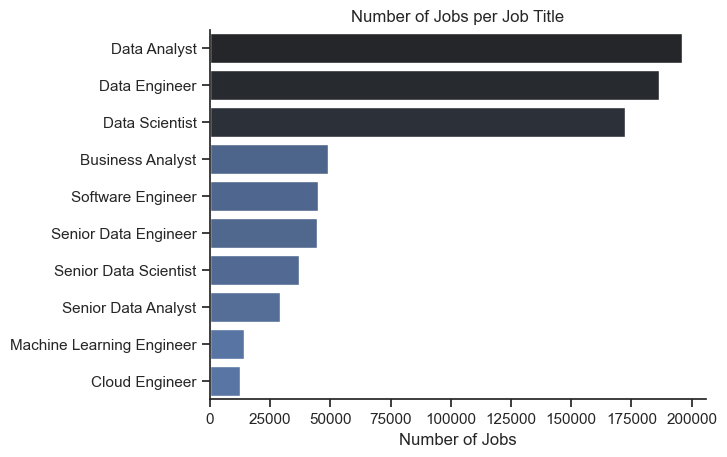

In [ ]:
df_plot = df['job_title_short'].value_counts()
df_plot = df_plot.to_frame()

sns.set_theme(style='ticks')
sns.barplot(data= df_plot , x='count', y ='job_title_short', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Number of Jobs per Job Title')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

Countries to Explore Globally 

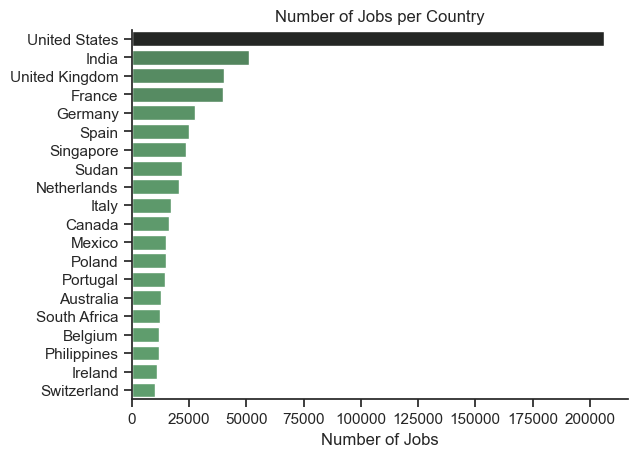

In [47]:
df_plot = df['job_country'].value_counts().to_frame().head(20)

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_country', hue='count', palette='dark:g_r', legend=False)
sns.despine()
plt.title('Number of Jobs per Country')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

Job Opportunities / Benefits

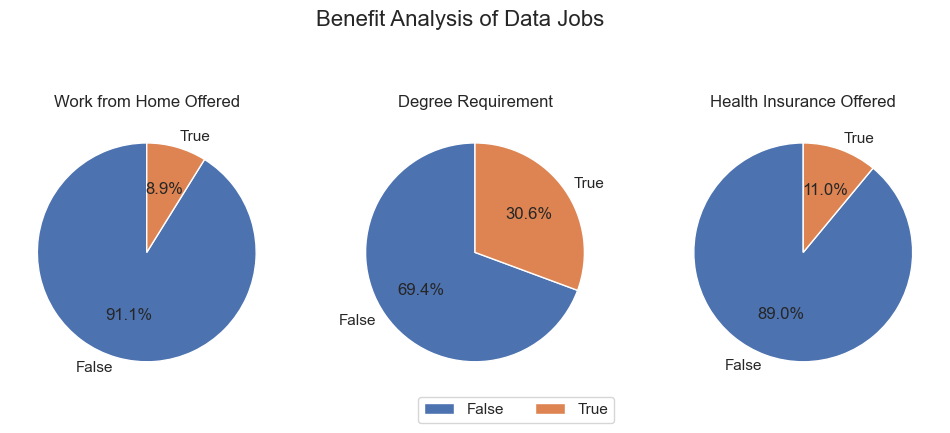

In [ ]:
dict_col= {
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'Degree Requirement',
    'job_health_insurance': 'Health Insurance Offered' }

fig, ax = plt.subplots(1, 3, figsize=(12, 5))

for i, (key,value) in enumerate(dict_col.items()):
    ax[i].pie(df[key].value_counts(),labels=['False', 'True'], autopct='%1.1f%%', startangle=90)  # Counting is done inside the loop to ensure the order of True/False matches the labels correctly.If done outside, the index order might mismatch.
    ax[i].set_title(value)

plt.suptitle('Benefit Analysis of Data Jobs', fontsize=16)
plt.legend(loc='upper center', bbox_to_anchor=(-0.55, 0), ncol=2)
plt.show()

Exploratory Data Analysis for Data Analysts in the US

Filter for US Data Analyst roles

In [50]:
df_DA_US = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')]

Salary Insights

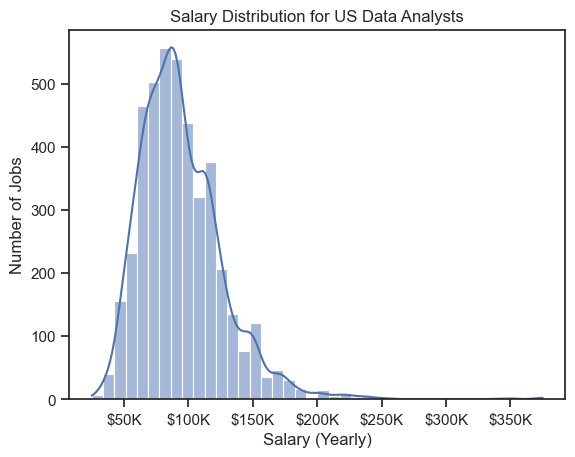

In [74]:
df_sal = df_DA_US['salary_year_avg'].dropna()
sns.histplot(df_sal, bins=40, kde=True)
plt.title('Salary Distribution for US Data Analysts')
plt.xlabel('Salary (Yearly)')
plt.ylabel('Number of Jobs')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
plt.show()

Locations to Explore:

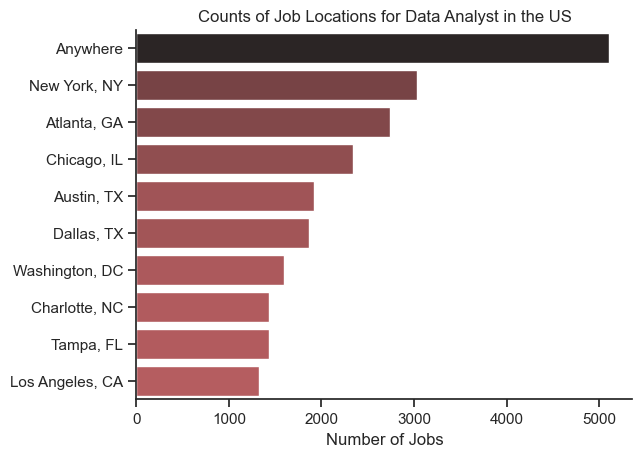

In [80]:
df_plot = df_DA_US['job_location'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette='dark:r_r', legend=False)
sns.despine()
plt.title('Counts of Job Locations for Data Analyst in the US')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

Companies to Explore:

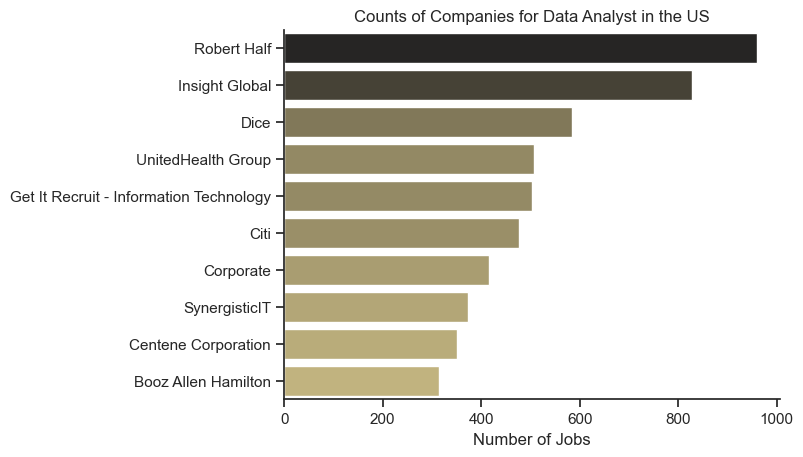

In [82]:
df_plot = df_DA_US['company_name'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:y_r', legend=False)
sns.despine()
plt.title('Counts of Companies for Data Analyst in the US')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()